In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [31]:
df = pd.read_csv("dataset.csv")
df.head()

,age,gender,cholesterol,blood_pressure,heart_rate,smoker,diabetes,exercise,target
0,52,M,230,140,85,Yes,No,Low,1
1,45,F,180,120,78,No,No,Medium,0
2,60,M,250,150,90,Yes,Yes,Low,1
3,39,F,170,110,70,No,No,High,0
4,48,M,210,130,80,Yes,No,Medium,1


In [32]:
print(df.shape)
print(df.columns)
df.dtypes

(30, 9)
Index(['age', 'gender', 'cholesterol', 'blood_pressure', 'heart_rate',
       'smoker', 'diabetes', 'exercise', 'target'],
      dtype='object')


age                int64
gender            object
cholesterol        int64
blood_pressure     int64
heart_rate         int64
smoker            object
diabetes          object
exercise          object
target             int64
dtype: object

In [33]:
df.isnull().sum()

age               0
gender            0
cholesterol       0
blood_pressure    0
heart_rate        0
smoker            0
diabetes          0
exercise          0
target            0
dtype: int64

In [34]:
df.duplicated().sum()
df = df.drop_duplicates()

In [35]:
df.describe()

,age,cholesterol,blood_pressure,heart_rate,target
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,48.833333,213.533333,132.166667,81.166667,0.533333
std,8.457126,36.806796,18.028872,9.142864,0.507416
min,34.000000,158.000000,102.000000,65.000000,0.000000
25%,42.250000,181.250000,118.500000,74.250000,0.000000
50%,48.500000,212.500000,131.000000,81.000000,1.000000
75%,55.750000,246.500000,147.500000,88.750000,1.000000
max,63.000000,272.000000,162.000000,96.000000,1.000000


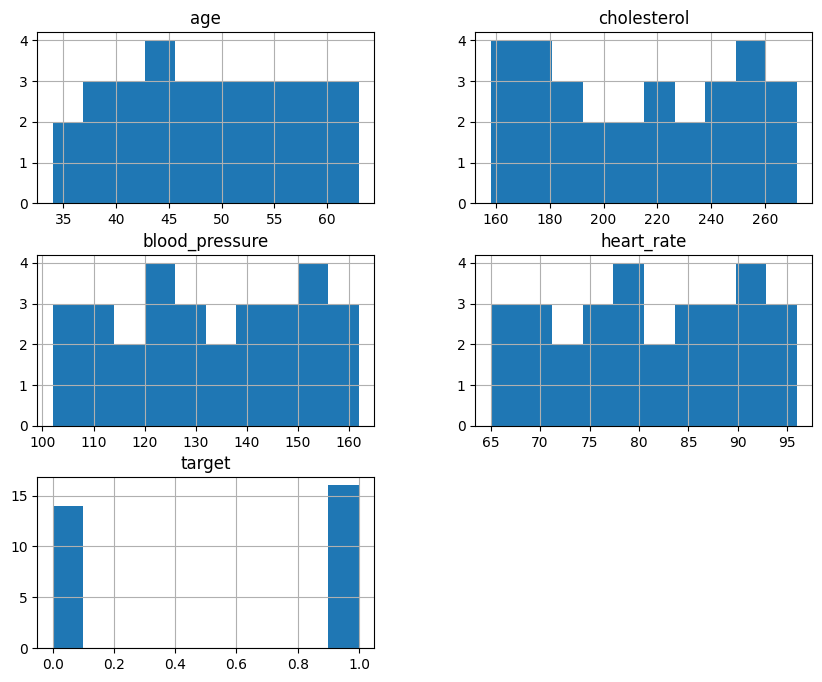

In [36]:
df.hist(figsize=(10,8))
plt.show()

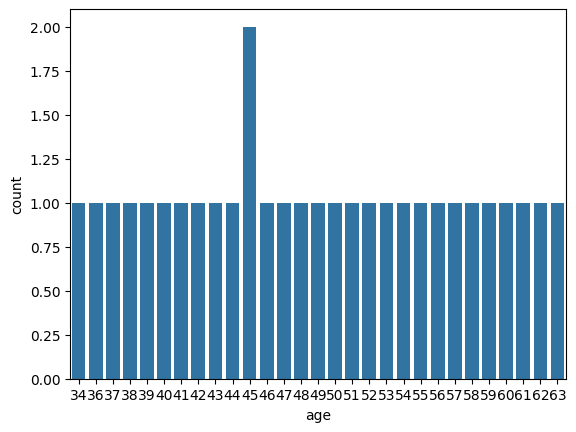

In [37]:
sns.countplot(x=df.iloc[:,0])
plt.show()

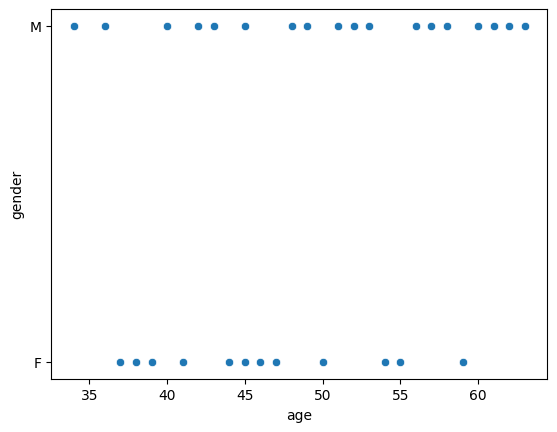

In [38]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])
plt.show()

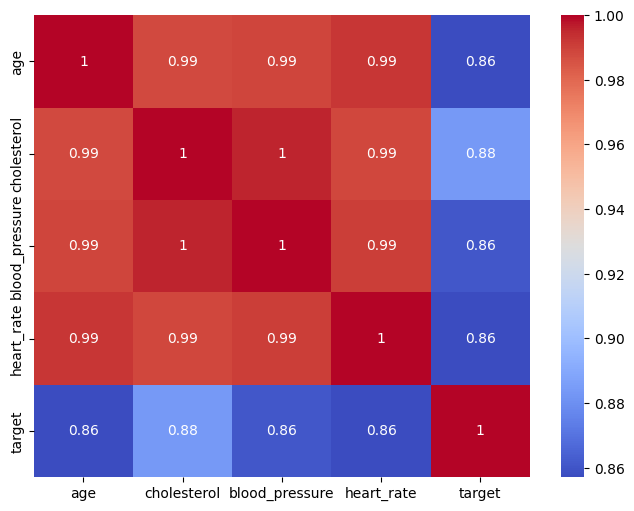

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.show()

In [40]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

In [41]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [42]:
scaler = StandardScaler()

X = df.drop("target", axis=1)
y = df["target"]

X_scaled = scaler.fit_transform(X)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [44]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [45]:
accuracy_score(y_test, y_pred)

1.0

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



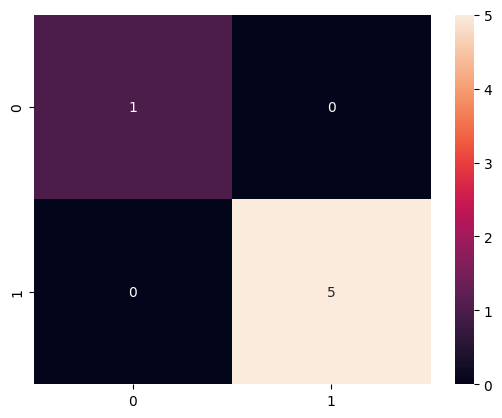

In [47]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

In [48]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy_score(y_test, y_pred_knn)

1.0

In [49]:
scores = cross_val_score(log_model, X_scaled, y, cv=5)

scores

array([1., 1., 1., 1., 1.])

In [50]:
scores.mean()

np.float64(1.0)

In [51]:
param_grid = {
    'n_neighbors': [3,5,7,9]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

grid.best_params_

{'n_neighbors': 3}

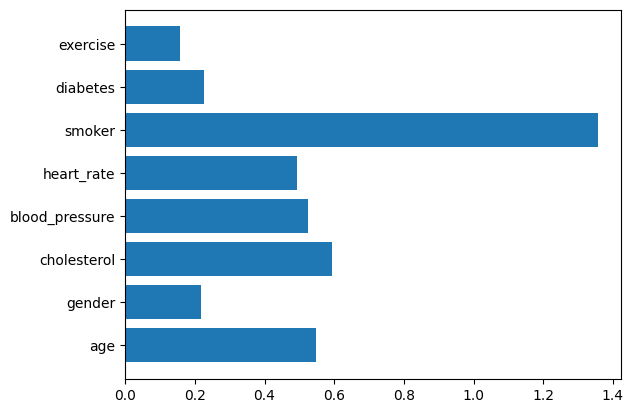

In [52]:
importance = log_model.coef_[0]

features = X.columns

plt.barh(features, importance)

plt.show()

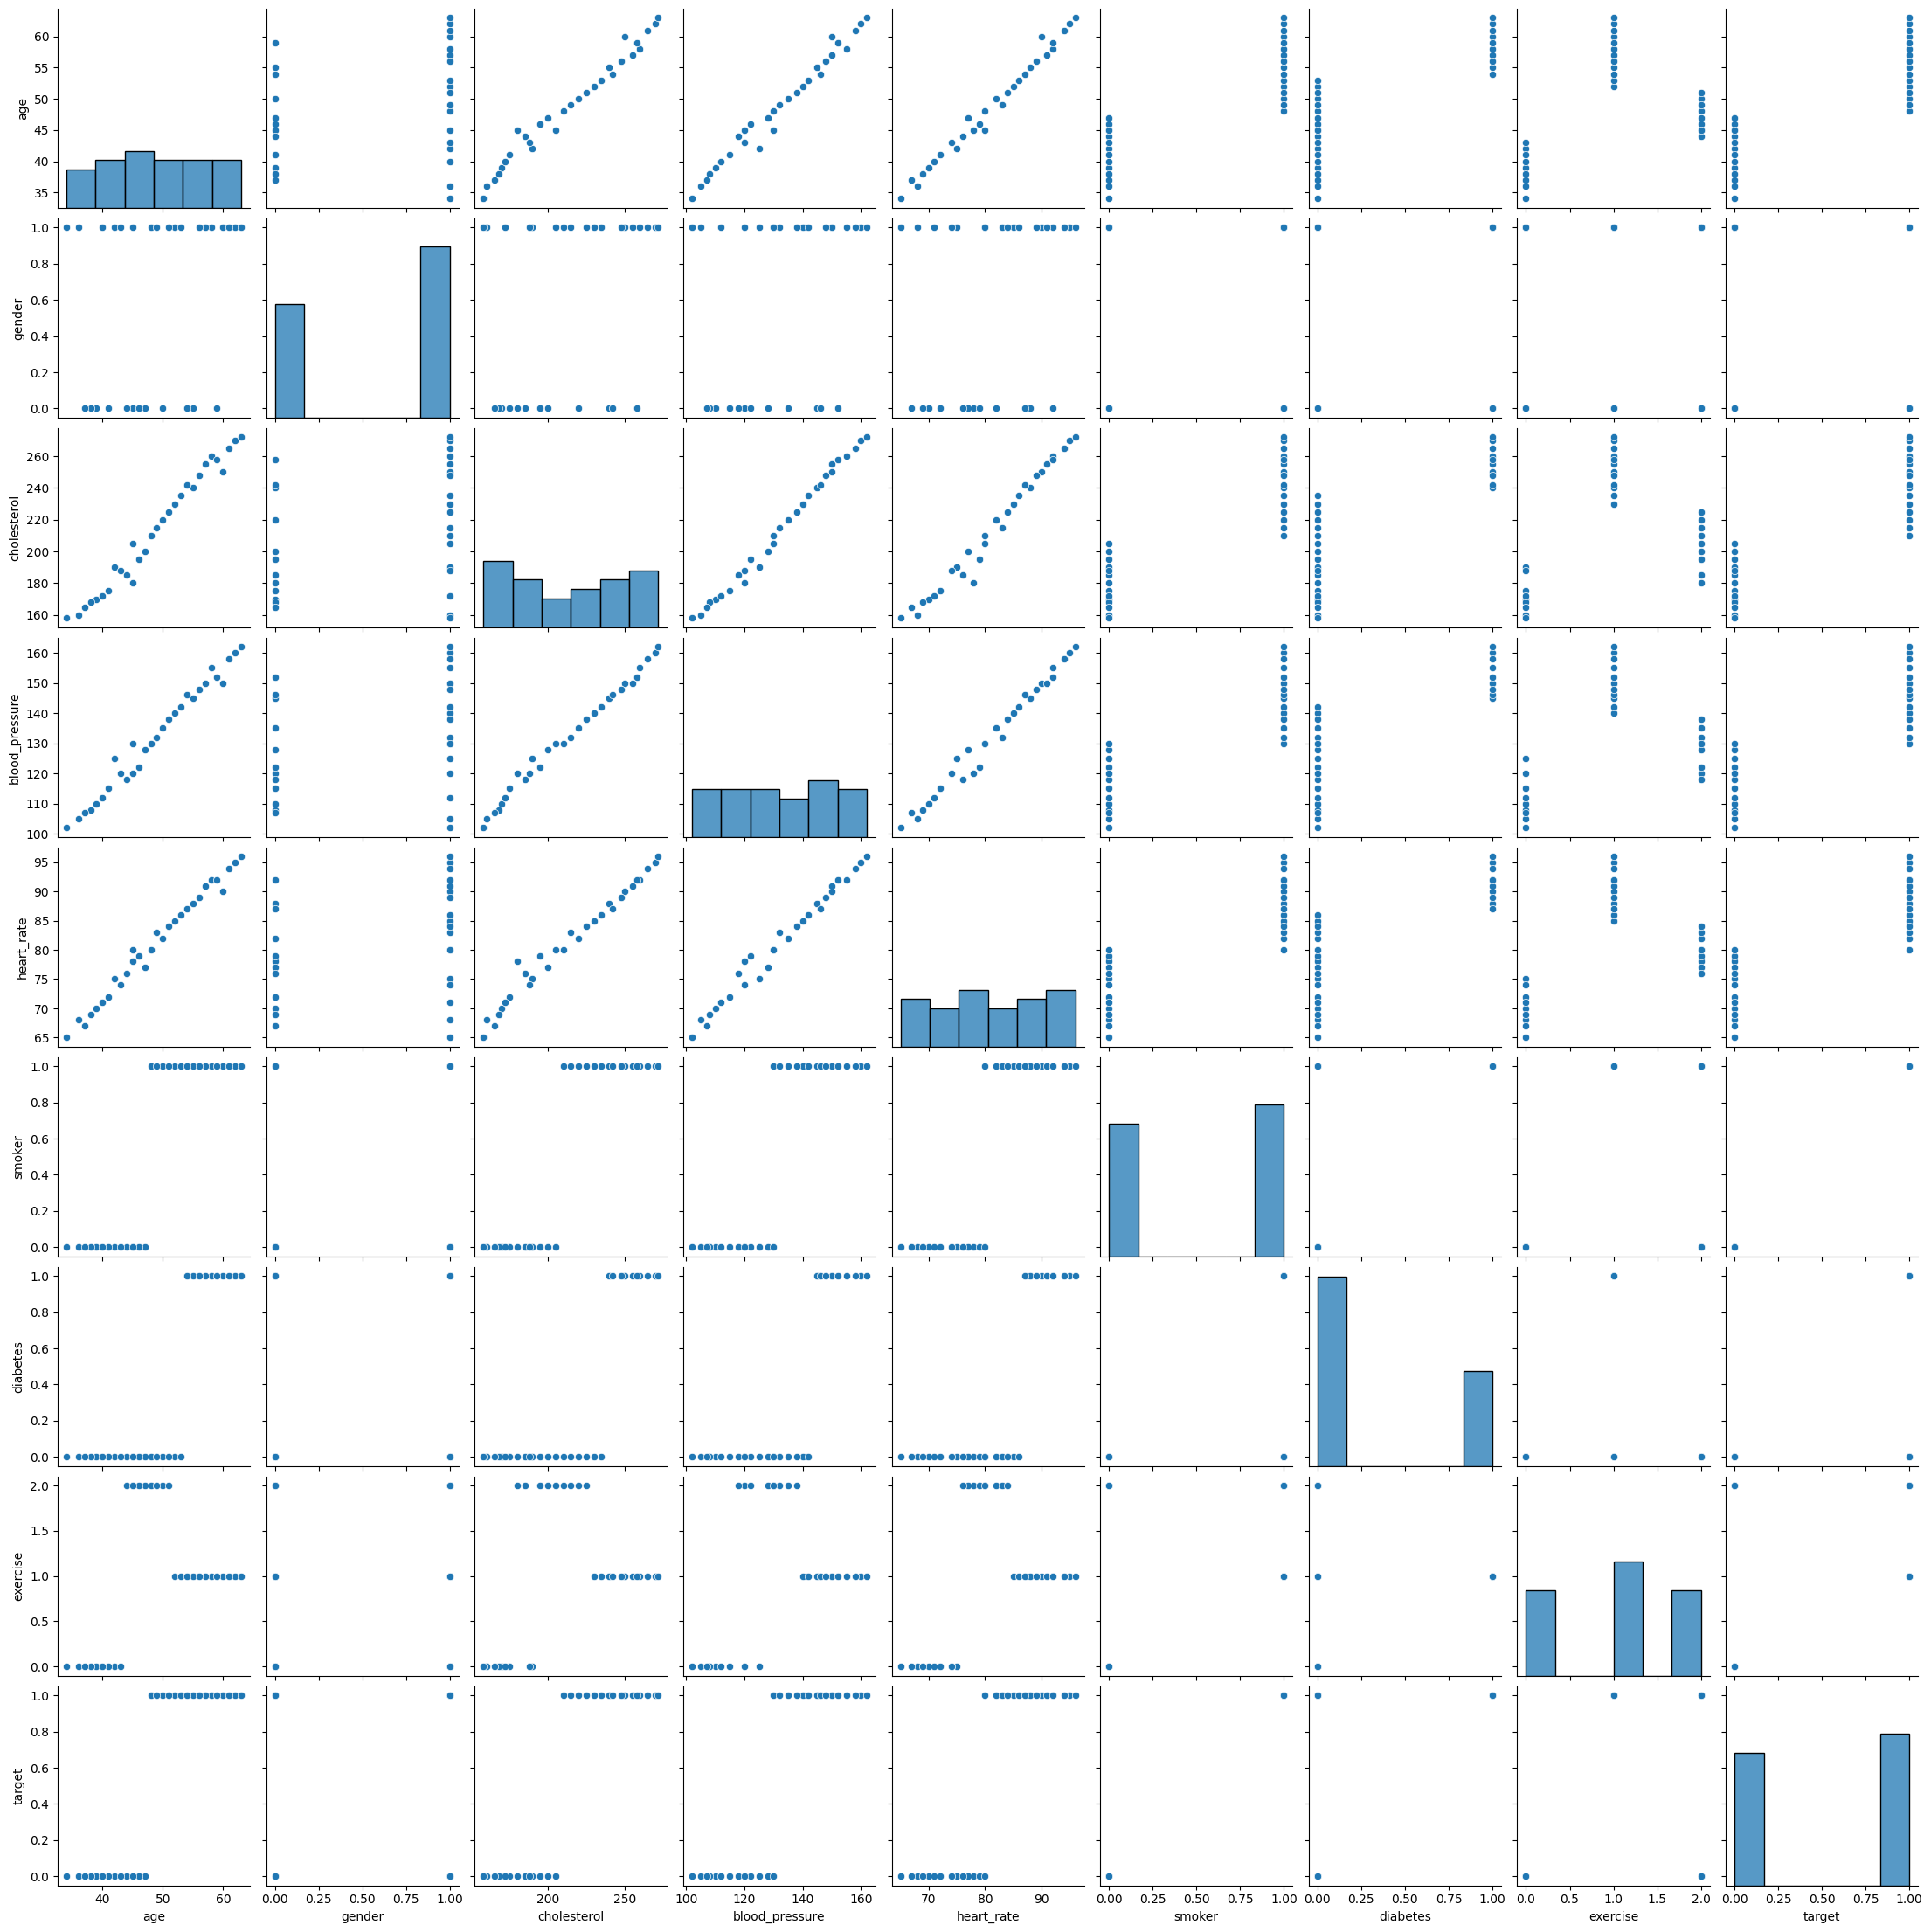

In [53]:
sns.pairplot(df)
plt.show()

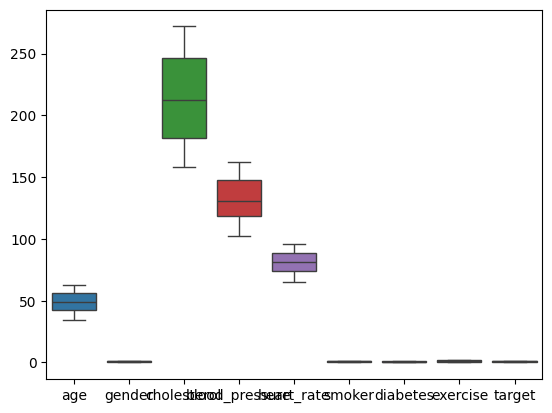

In [54]:
sns.boxplot(data=df)
plt.show()